# Persiapan

In [9]:
import matplotlib.pyplot as plt
import numpy as numpy
import seaborn as sns
import hdbscan
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler 

## 1. Pilih salah satu dataset nyata dari sklearn.datasets (misalnya iris dataset atau digits dataset).

In [10]:
iris = load_iris()
x = iris.data
y = iris.target

## 2. Lakukan clustering dengan HDBSCAN.


In [11]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, gen_min_span_tree=True)
cluster = StandardScaler().fit_transform(x)
cluster = StandardScaler().fit_transform(x)

## 3. Laporkan hasil:
    - Jumlah cluster yang terbentuk.
    - Banyaknya noise
    - Visualisasi (gunakan PCA/TSNE untuk reduksi dimensi jika perlu)

In [14]:
cluster_labels = clusterer.fit_predict(cluster)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(clusterer.labels_).count(-1)
print(f"Jumlah cluster yang terbentuk: {n_clusters}")
print(f"Jumlah noise points: {n_noise}")

Jumlah cluster yang terbentuk: 2
Jumlah noise points: 2


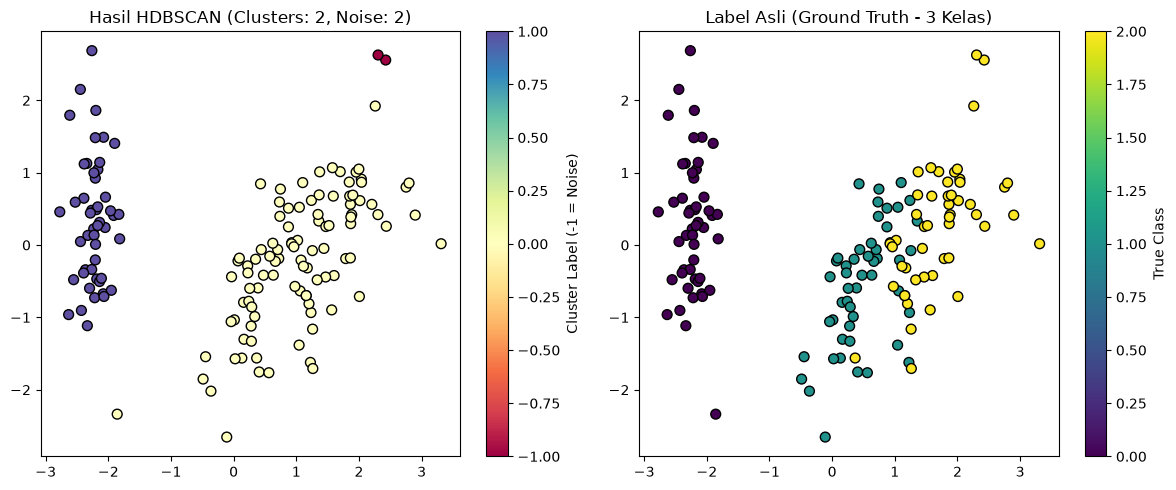

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(cluster)
y_true = y

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='Spectral', s=50, edgecolor='k')
plt.title(f'Hasil HDBSCAN (Clusters: {n_clusters}, Noise: {n_noise})')
plt.colorbar(scatter, label='Cluster Label (-1 = Noise)')

plt.subplot(1, 2, 2)
scatter_true = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=50, edgecolor='k')
plt.title('Label Asli (Ground Truth - 3 Kelas)')
plt.colorbar(scatter_true, label='True Class')

plt.tight_layout()
plt.show()


## 4. Buat analisis singkat: apakah hasil clustering HDBSCAN sesuai dengan label asli dataset tersebut?

Hasil clustering menggunakan HDBSCAN menunjukkan kesesuaian parsial dengan label asli dataset Iris. Algoritma ini sangat andal dalam memisahkan spesies Iris-setosa secara sempurna karena karakteristiknya yang terpisah secara tegas dari spesies lain. Namun, untuk spesies Iris-versicolor dan Iris-virginica yang saling tumpang tindih (overlapping), HDBSCAN cenderung menggabungkannya ke dalam satu kelompok atau mendeteksinya sebagai noise. Secara keseluruhan